# ============================================================
# EXDARK DATA PREPROCESSING
# ============================================================
#
# During preprocessing, we prepared the ExDark dataset for
# YOLO object detection while preserving the original images.
#
# 1. DATASET ORGANIZATION
#    - Organized the dataset into three splits:
#        train/  -> 5,147 images
#        valid/  -> 1,099 images
#        test/   -> 1,116 images
#    - Ensured that every image had a corresponding YOLO
#      annotation (.txt) file.
#    - Final dataset: 7,362 valid image-label pairs.
#
# 2. ANNOTATION FORMAT
#    - Used YOLO-format bounding-box annotations:
#        class_id, x_center, y_center, width, height
#    - Coordinates were represented as normalized values
#      between 0 and 1.
#
# 3. ANNOTATION VALIDATION
#    - Checked that annotation files existed for all images.
#    - Checked that every label contained valid bounding-box
#      information.
#    - Verified that class IDs were within the 12 ExDark classes.
#    - Verified that bounding-box coordinates were valid.
#
# 4. CLASS DEFINITIONS
#    - The dataset contains 12 object classes:
#      Bicycle, Boat, Bottle, Bus, Car, Cat, Chair, Cup,
#      Dog, Motorbike, People, Table.
#
# 5. DATASET CONFIGURATION
#    - Created/verified data.yaml containing:
#        * dataset path
#        * training image path
#        * validation image path
#        * test image path
#        * number of classes
#        * class names
#
# 6. TRAINING PREPARATION
#    - The dataset was copied from Google Drive to Colab's
#      local storage to reduce the I/O bottleneck caused by
#      reading thousands of images directly from Google Drive.
#    - Images were resized to 640x640 during YOLO training.
#    - YOLO automatically handled the required image
#      normalization and augmentation during training.
#
# 7. DATA LEAKAGE PREVENTION
#    - Training, validation, and test images were kept in
#      separate folders.
#    - The test set was not used for model training.
#
# The final dataset was therefore ready for training and
# evaluating YOLO11s and YOLO26s under the same conditions.
# ============================================================

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

print("Dataset contents:")
for item in os.listdir(DATASET_PATH):
    print(item)

Dataset contents:
test
runs
train
valid
data.yaml


In [3]:
DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

with open(f"{DATASET_PATH}/data.yaml", "r") as f:
    print(f.read())

path: /content/drive/MyDrive/ExDark_YOLO
train: train/images
val: valid/images
test: test/images

nc: 12

names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table



In [4]:
DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

yaml_content = """path: /content/drive/MyDrive/ExDark_YOLO
train: train/images
val: valid/images
test: test/images

nc: 12

names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table
"""

with open(f"{DATASET_PATH}/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully.")

data.yaml updated successfully.


In [5]:
print(open(f"{DATASET_PATH}/data.yaml").read())

path: /content/drive/MyDrive/ExDark_YOLO
train: train/images
val: valid/images
test: test/images

nc: 12

names:
  0: Bicycle
  1: Boat
  2: Bottle
  3: Bus
  4: Car
  5: Cat
  6: Chair
  7: Cup
  8: Dog
  9: Motorbike
  10: People
  11: Table



In [6]:
import os

DATASET_PATH = "/content/drive/MyDrive/ExDark_YOLO"

for split in ["train", "valid", "test"]:
    images_path = os.path.join(DATASET_PATH, split, "images")
    labels_path = os.path.join(DATASET_PATH, split, "labels")

    images = [f for f in os.listdir(images_path)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    labels = [f for f in os.listdir(labels_path)
              if f.endswith(".txt")]

    print(f"{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

train:
  Images: 5147
  Labels: 5147
valid:
  Images: 1099
  Labels: 1099
test:
  Images: 1116
  Labels: 1116


In [7]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [8]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.4 MB/s eta 0:00:00


In [9]:
!cp -r "/content/drive/MyDrive/ExDark_YOLO" "/content/"

In [10]:
import ultralytics
from ultralytics import YOLO
import torch
import os

# --------------------------------------------------
# EXDARK YOLO BASELINE EXPERIMENT
# --------------------------------------------------

DATASET_PATH = "/content/ExDark_YOLO"
DATA_YAML = f"{DATASET_PATH}/data.yaml"

# Model
MODEL_NAME = "yolo11s.pt"

# Training configuration
EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 16

# Device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("========================================")
print("ExDark YOLO Training Configuration")
print("========================================")
print(f"Model:       {MODEL_NAME}")
print(f"Epochs:      {EPOCHS}")
print(f"Batch size:  {BATCH_SIZE}")
print(f"Image size:  {IMG_SIZE}")
print(f"Device:      {DEVICE}")
print(f"GPU:         {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("========================================")

model = YOLO(MODEL_NAME)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=f"{DATASET_PATH}/runs",
    name="exdark_yolo11s_10epochs",
    exist_ok=True,
    pretrained=True,
    verbose=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
ExDark YOLO Training Configuration
Model:       yolo11s.pt
Epochs:      10
Batch size:  16
Image size:  640
Device:      0
GPU:         Tesla T4
Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ExDark_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dn

In [11]:
RUN_DIR = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs"

print("Training files:")
for item in os.listdir(RUN_DIR):
    print(item)

Training files:
results.csv
BoxR_curve.png
train_batch1.jpg
val_batch2_pred.jpg
confusion_matrix_normalized.png
val_batch1_pred.jpg
weights
val_batch1_labels.jpg
results.png
BoxPR_curve.png
BoxP_curve.png
val_batch2_labels.jpg
confusion_matrix.png
labels.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
train_batch0.jpg
BoxF1_curve.png
args.yaml


In [12]:

MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"
DATA_YAML = "/content/ExDark_YOLO/data.yaml"

model = YOLO(MODEL_PATH)

test_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 57.6±6.6 MB/s, size: 220.4 KB)
val: Scanning /content/drive/MyDrive/ExDark_YOLO/test/labels.cache... 1116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1116/1116 260.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 70/70 3.2it/s 22.2s
                   all       1116       3406      0.734      0.664      0.735      0.479
               Bicycle        113        164       0.78      0.732      0.793      0.533
                  Boat        104        211      0.731      0.592      0.682       0.36
                Bottle        107        187      0.741      0.657      0.724      0.479
                   Bus         85        113      0.911      0.817      0.896      0.694
                   Car   

In [13]:
print("Precision:", test_results.box.mp)
print("Recall:", test_results.box.mr)
print("mAP@50:", test_results.box.map50)
print("mAP@50:95:", test_results.box.map)

Precision: 0.733940847867193
Recall: 0.663638241769329
mAP@50: 0.7345310900195022
mAP@50:95: 0.4787897033391825


In [14]:
import os
import random

TEST_IMAGES = "/content/ExDark_YOLO/test/images"

image_files = [
    f for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
selected_images = random.sample(image_files, min(10, len(image_files)))

print("Selected test images:")
for image in selected_images:
    print(image)

Selected test images:
2015_07118.jpg
2015_02980.jpg
2015_03126.jpg
2015_06162.jpg
2015_06443.jpg
2015_02284.jpg
2015_04088.jpg
2015_03863.jpg
2015_00961.jpg
2015_06640.JPEG


In [15]:
MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"

model = YOLO(MODEL_PATH)

selected_paths = [
    os.path.join(TEST_IMAGES, image)
    for image in selected_images
]

results = model.predict(
    source=selected_paths,
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/content/ExDark_YOLO/runs",
    name="test_images_predictions",
    exist_ok=True
)


0: 640x640 1 Chair, 1 Cup, 2 Peoples, 1 Table, 10.6ms
1: 640x640 3 Cars, 10.6ms
2: 640x640 1 Cat, 1 Dog, 1 People, 10.6ms
3: 640x640 1 Motorbike, 10.6ms
4: 640x640 2 Peoples, 10.6ms
5: 640x640 1 Bus, 10.6ms
6: 640x640 1 Chair, 1 Table, 10.6ms
7: 640x640 1 Chair, 1 Table, 10.6ms
8: 640x640 5 Boats, 10.6ms
9: 640x640 3 Bottles, 4 Peoples, 10.6ms
Speed: 1.8ms preprocess, 10.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/ExDark_YOLO/runs/test_images_predictions



2015_07118.jpg


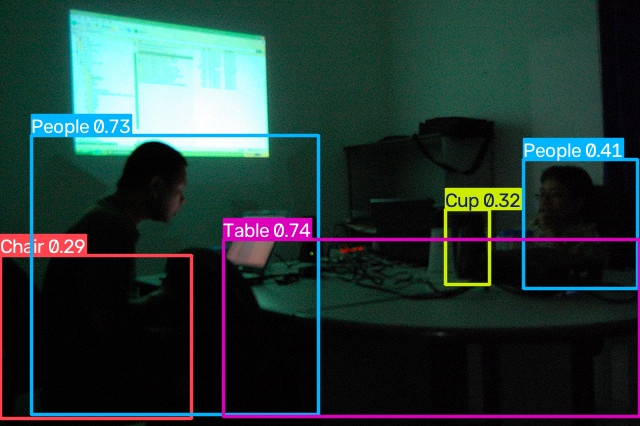


2015_02980.jpg


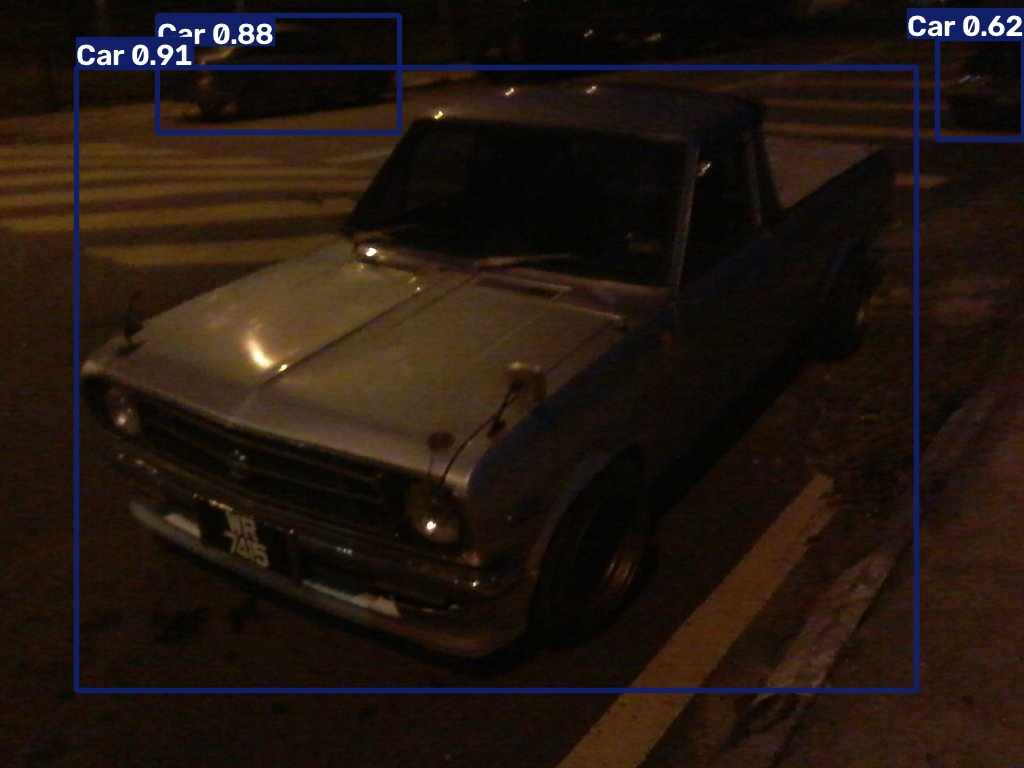


2015_03126.jpg


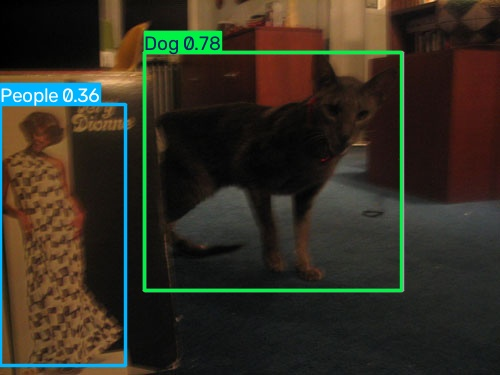


2015_06162.jpg


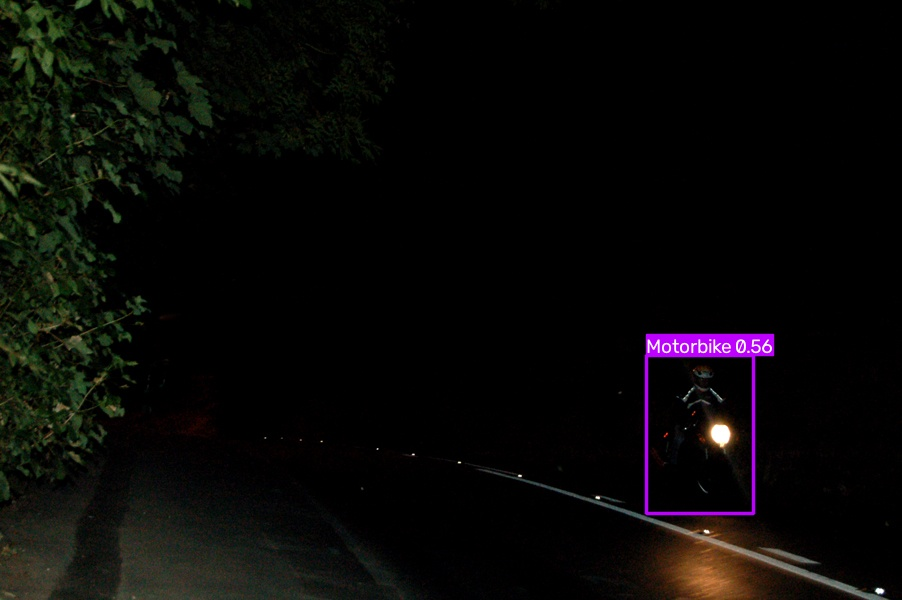


2015_06443.jpg


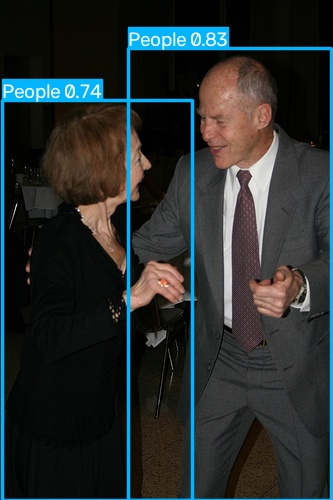


2015_02284.jpg


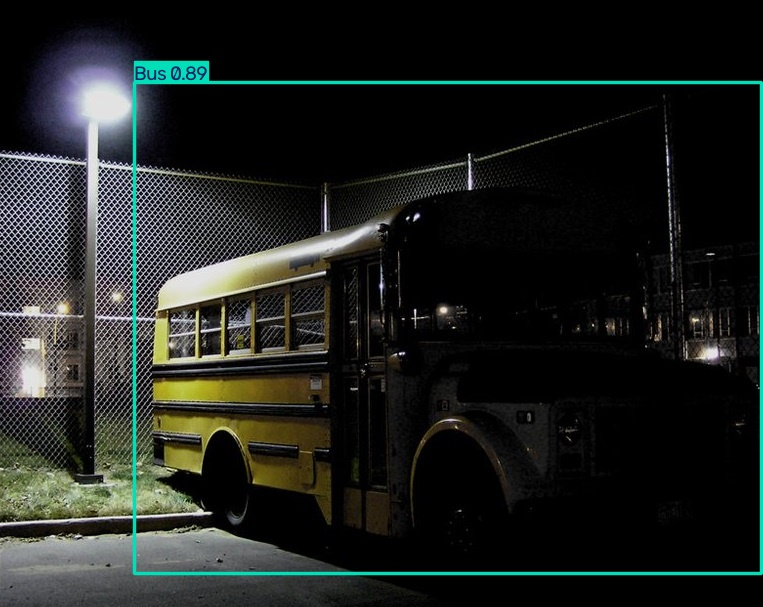


2015_04088.jpg


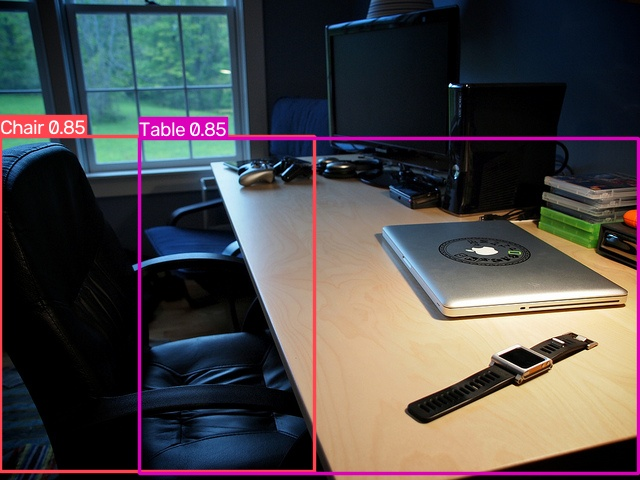


2015_03863.jpg


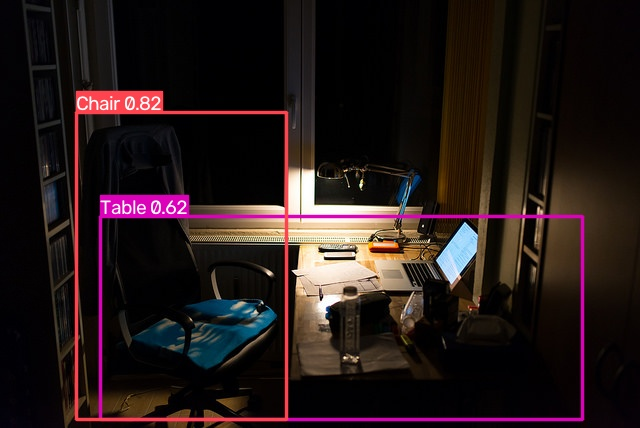


2015_00961.jpg


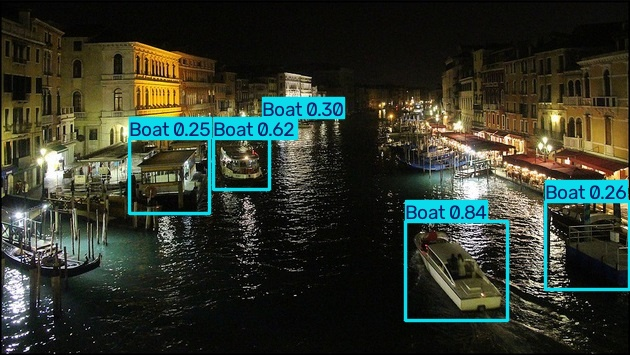

In [16]:
from IPython.display import display, Image

OUTPUT_DIR = "/content/ExDark_YOLO/runs/test_images_predictions"

for image in selected_images:
    output_path = os.path.join(OUTPUT_DIR, image)

    if os.path.exists(output_path):
        print(f"\n{image}")
        display(Image(filename=output_path))

In [17]:
!pip install -q gradio

In [18]:
import time

MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"

model = YOLO(MODEL_PATH)

TEST_IMAGES = "/content/ExDark_YOLO/test/images"

image_files = [
    os.path.join(TEST_IMAGES, f)
    for f in os.listdir(TEST_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Use a small fixed sample
image_files = image_files[:50]

start = time.time()

for image in image_files:
    model.predict(
        source=image,
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )

elapsed = time.time() - start

print(f"Images processed: {len(image_files)}")
print(f"Total time: {elapsed:.2f} seconds")
print(f"Average time/image: {elapsed/len(image_files):.4f} seconds")
print(f"Approximate FPS: {len(image_files)/elapsed:.2f}")

Images processed: 50
Total time: 2.39 seconds
Average time/image: 0.0477 seconds
Approximate FPS: 20.96


In [19]:
import torch

DATA_YAML = "/content/ExDark_YOLO/data.yaml"

model2 = YOLO("yolo26s.pt")

results2 = model2.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/ExDark_YOLO/runs",
    name="exdark_yolo26s_10epochs",
    exist_ok=True,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ExDark_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exdark_yolo26s_10epochs, nbs=64, nms=None, opset=None, opti

In [20]:
MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo26s_10epochs/weights/best.pt"
DATA_YAML = "/content/ExDark_YOLO/data.yaml"

model26 = YOLO(MODEL_PATH)

test_results = model26.val(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/ExDark_YOLO/runs",
    name="exdark_yolo26s_10epochs",
    exist_ok=True,
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,469,824 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 102.7±61.6 MB/s, size: 165.3 KB)
val: Scanning /content/drive/MyDrive/ExDark_YOLO/valid/labels.cache... 1099 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1099/1099 307.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 2.4it/s 29.2s
                   all       1099       3516      0.791      0.739      0.801      0.536
               Bicycle        111        147      0.878      0.781      0.858      0.603
                  Boat        102        230      0.716      0.743      0.756      0.438
                Bottle        111        251      0.778      0.616      0.686      0.425
                   Bus         85        109      0.874      0.936      0.964      0.789
                   Car

In [21]:
print("========================================")
print("YOLO26s TEST METRICS")
print("========================================")

print(f"Precision     : {test_results.box.mp:.4f}")
print(f"Recall        : {test_results.box.mr:.4f}")
print(f"mAP@50        : {test_results.box.map50:.4f}")
print(f"mAP@50:95     : {test_results.box.map:.4f}")

YOLO26s TEST METRICS
Precision     : 0.7911
Recall        : 0.7386
mAP@50        : 0.8009
mAP@50:95     : 0.5359


Testing new data with the 2 models

In [22]:
results11 = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project="/content/ExDark_YOLO/runs",
    name="yolo11s_test_evaluation",
    exist_ok=True
)

results26 = model2.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project="/content/ExDark_YOLO/runs",
    name="yolo26s_test_evaluation",
    exist_ok=True
)

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,417,444 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.8±1.2 ms, read: 47.0±34.8 MB/s, size: 237.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/ExDark_YOLO/test/labels.cache... 1116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1116/1116 187.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 70/70 2.5it/s 27.5s
                   all       1116       3406      0.734      0.664      0.735      0.479
               Bicycle        113        164       0.78      0.732      0.793      0.533
                  Boat        104        211      0.731      0.592      0.682       0.36
                Bottle        107        187   

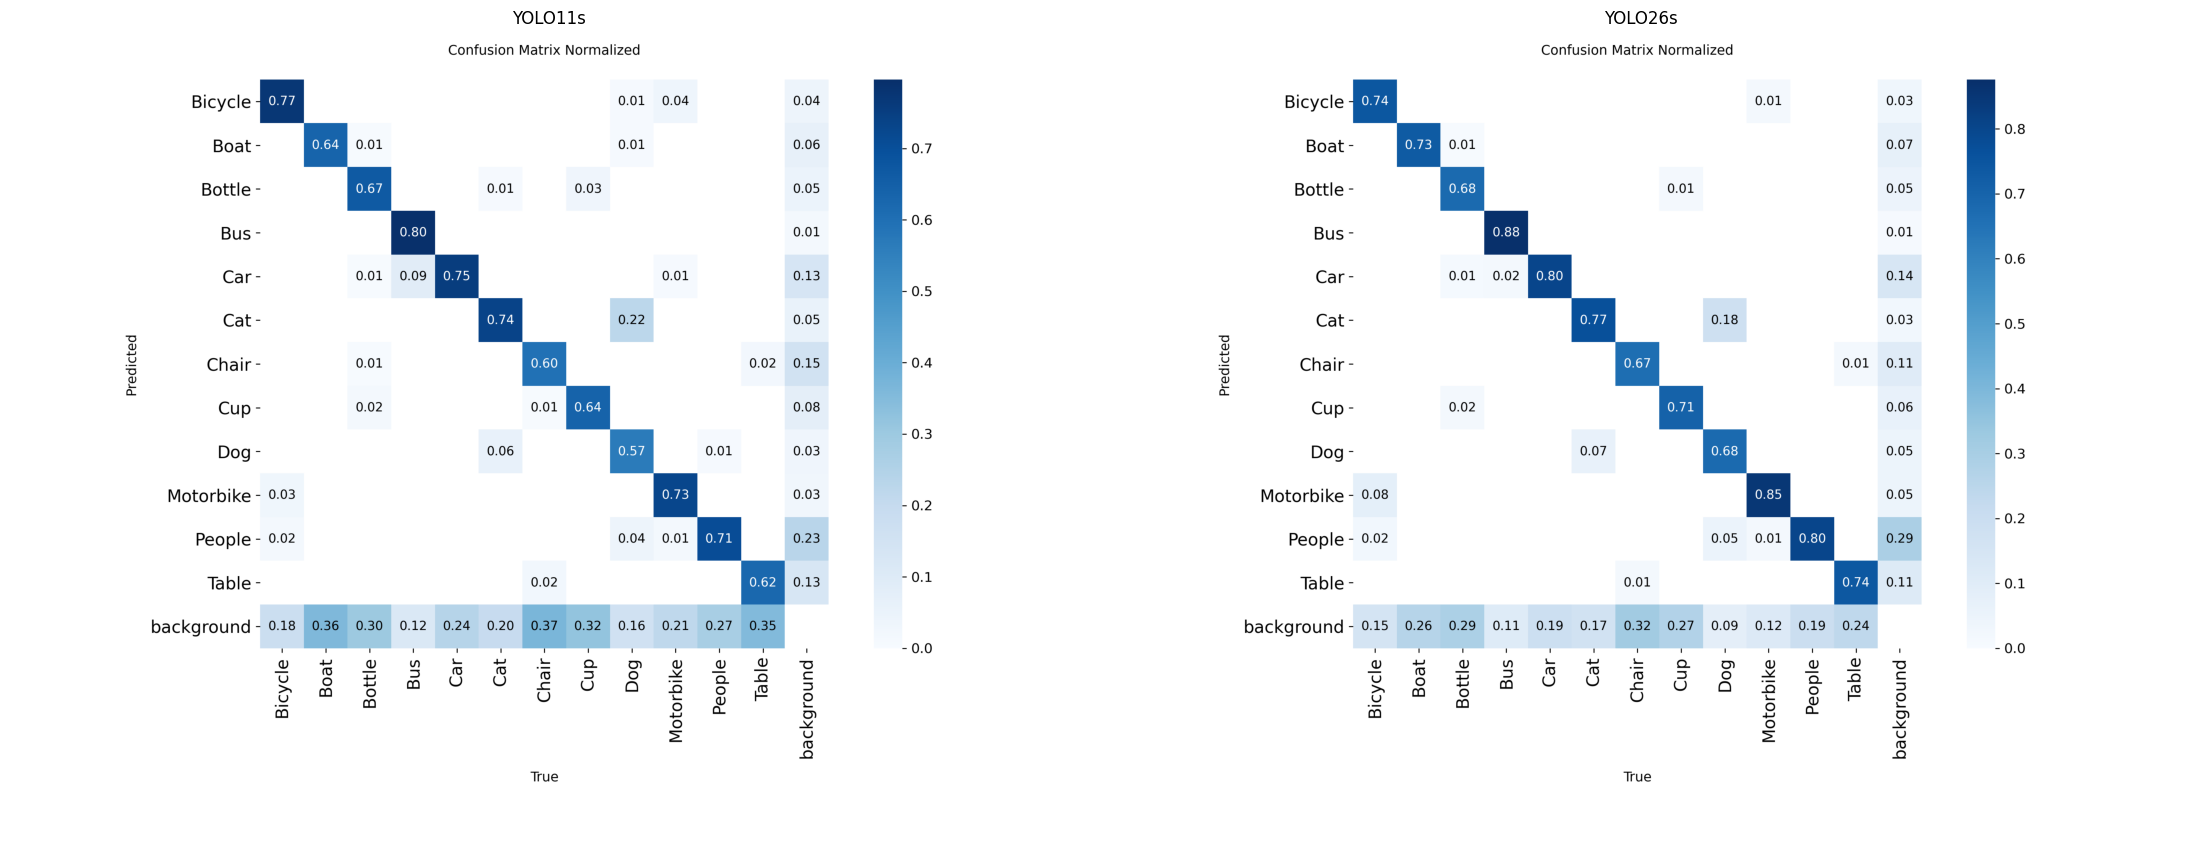

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

cm11 = "/content/ExDark_YOLO/runs/yolo11s_test_evaluation/confusion_matrix_normalized.png"
cm26 = "/content/ExDark_YOLO/runs/yolo26s_test_evaluation/confusion_matrix_normalized.png"

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

axes[0].imshow(Image.open(cm11))
axes[0].set_title("YOLO11s")
axes[0].axis("off")

axes[1].imshow(Image.open(cm26))
axes[1].set_title("YOLO26s")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50:95"
    ],
    "YOLO11s": [
        results11.box.mp,
        results11.box.mr,
        results11.box.map50,
        results11.box.map
    ],
    "YOLO26s": [
        results26.box.mp,
        results26.box.mr,
        results26.box.map50,
        results26.box.map
    ]
})

metrics_df

,Metric,YOLO11s,YOLO26s
0,Precision,0.733941,0.810033
1,Recall,0.663638,0.713932
2,mAP@50,0.734531,0.802354
3,mAP@50:95,0.478790,0.536886


In [25]:
import gradio as gr

# Load trained model
MODEL_PATH = "/content/ExDark_YOLO/runs/exdark_yolo11s_10epochs/weights/best.pt"
model = YOLO(MODEL_PATH)

def detect_objects(image):
    results = model.predict(
        source=image,
        imgsz=640,
        conf=0.25,
        device=0
    )

    # Annotated image
    annotated_image = results[0].plot()

    return annotated_image

demo = gr.Interface(
    fn=detect_objects,
    inputs=gr.Image(type="numpy", label="Upload an image"),
    outputs=gr.Image(label="YOLO11s Predictions"),
    title="ExDark YOLO Object Detection",
    description="Upload an image to detect objects using the trained YOLO11s model."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://681aff9e0f4bf9cd9a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
